In [52]:
import pandas as pd
import numpy as np

### Regression

- F(X) = f0(X) + f1(X) + f2(X) ...

- f0(X) is mean of output column
- other functions are decision trees

In [53]:
# Creating a dummy dataset
r_and_d = np.random.randint(1,200,size=100)
marketing = np.random.randint(1,200,size=100)
profit = np.random.randint(1,200,size=100)
df = pd.DataFrame(zip(r_and_d,marketing,profit),columns=['R&D','Marketing','Profit'])

In [54]:
sample_df = df.sample(3)

In [55]:
sample_df

,R&D,Marketing,Profit
69,33,25,81
62,158,186,181
27,120,181,119


In [56]:
mean = np.mean(sample_df['Profit'])

In [57]:
mean

np.float64(127.0)

In [58]:
f0_x = round(mean,2)

In [59]:
sample_df['f0(x)'] = f0_x

In [60]:
sample_df

,R&D,Marketing,Profit,f0(x)
69,33,25,81,127.0
62,158,186,181,127.0
27,120,181,119,127.0


In [61]:
# finding pseudo residual
sample_df['residual1'] = sample_df['Profit']-sample_df['f0(x)']

In [62]:
sample_df

,R&D,Marketing,Profit,f0(x),residual1
69,33,25,81,127.0,-46.0
62,158,186,181,127.0,54.0
27,120,181,119,127.0,-8.0


In [63]:
X = sample_df.iloc[:,0:2]

In [64]:
y_1 = sample_df['residual1']

In [65]:
X,y_1

(    R&D  Marketing
 69   33         25
 62  158        186
 27  120        181,
 69   -46.0
 62    54.0
 27    -8.0
 Name: residual1, dtype: float64)

In [66]:
# creating decision tree
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [67]:
dt1 = DecisionTreeRegressor(max_depth=1)

In [68]:
dt1.fit(X,y_1)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
y_pred_1 = dt1.predict(X)

In [70]:
y_pred_1

array([-27.,  54., -27.])

[Text(0.5, 0.75, 'x[1] <= 183.5\nsquared_error = 1698.667\nsamples = 3\nvalue = 0.0'),
 Text(0.25, 0.25, 'squared_error = 361.0\nsamples = 2\nvalue = -27.0'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = 54.0'),
 Text(0.625, 0.5, '  False')]

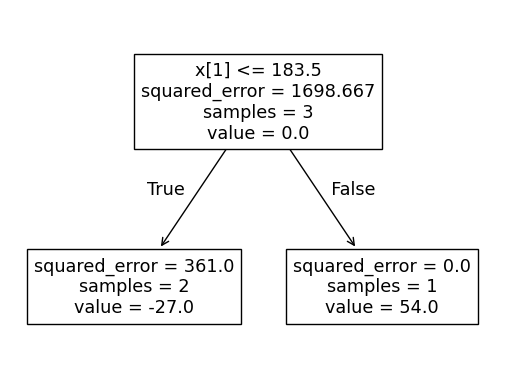

In [71]:
plot_tree(dt1)

In [72]:
109.33+(-43.33)

66.0

In [73]:
sample_df['f1(x)']=sample_df['f0(x)']+y_pred_1

In [74]:
sample_df

,R&D,Marketing,Profit,f0(x),residual1,f1(x)
69,33,25,81,127.0,-46.0,100.0
62,158,186,181,127.0,54.0,181.0
27,120,181,119,127.0,-8.0,100.0


In [75]:
sample_df['residual2']=sample_df['Profit']-sample_df['f1(x)']

In [76]:
sample_df

,R&D,Marketing,Profit,f0(x),residual1,f1(x),residual2
69,33,25,81,127.0,-46.0,100.0,-19.0
62,158,186,181,127.0,54.0,181.0,0.0
27,120,181,119,127.0,-8.0,100.0,19.0


### Classification

- Everything is same in classification, but the loss function geys changed

- Instead of using mse we use logloss

In [86]:
# cgpa	iq	placement
# 0	6.8	123.0	1
# 1	5.9	106.0	0
# 2	5.3	121.0	0
# 3	7.4	132.0	1
# 4	5.8	142.0	0
data = {
    'cgpa':[6.8,5.9,5.3,7.4,5.8],
    'iq':[123,106,121,132,142],
    'placement':[1,0,0,1,0]
}
placement_df = pd.DataFrame(data)

In [87]:
placement_df

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


- here f0(x) = loge(number of 1s/number of 0s) ---> this is called log(odds) -> read as log of odds

f0(x) = loge(2/3) = -0.405

In [88]:
placement_df['f0(x)'] = -0.405

In [89]:
placement_df

,cgpa,iq,placement,f0(x)
0,6.8,123,1,-0.405
1,5.9,106,0,-0.405
2,5.3,121,0,-0.405
3,7.4,132,1,-0.405
4,5.8,142,0,-0.405


In [90]:
placement_df['prob1'] = 0.4001

In [91]:
placement_df

,cgpa,iq,placement,f0(x),prob1
0,6.8,123,1,-0.405,0.4001
1,5.9,106,0,-0.405,0.4001
2,5.3,121,0,-0.405,0.4001
3,7.4,132,1,-0.405,0.4001
4,5.8,142,0,-0.405,0.4001


In [92]:
placement_df['residual1']=placement_df['placement']-placement_df['prob1']

In [93]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1
0,6.8,123,1,-0.405,0.4001,0.5999
1,5.9,106,0,-0.405,0.4001,-0.4001
2,5.3,121,0,-0.405,0.4001,-0.4001
3,7.4,132,1,-0.405,0.4001,0.5999
4,5.8,142,0,-0.405,0.4001,-0.4001


In [114]:
plc_dt = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

In [115]:
plc_dt.fit(placement_df.iloc[:,0:2].values, placement_df['residual1'].values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,3
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.75, 'node #0\ncgpa <= 6.35\nsquared_error = 0.24\nsamples = 5\nvalue = -0.0'),
 Text(0.25, 0.25, 'node #1\nsquared_error = 0.0\nsamples = 3\nvalue = -0.4'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'node #2\nsquared_error = 0.0\nsamples = 2\nvalue = 0.6'),
 Text(0.625, 0.5, '  False')]

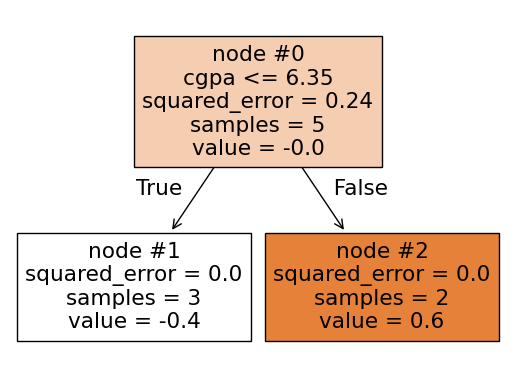

In [116]:
plot_tree(plc_dt, feature_names=['cgpa','iq'],filled=True, node_ids=True)

In [99]:
placement_df['leaf_nodes'] = plc_dt.apply(placement_df.iloc[:,0:2])

In [100]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes
0,6.8,123,1,-0.405,0.4001,0.5999,2
1,5.9,106,0,-0.405,0.4001,-0.4001,1
2,5.3,121,0,-0.405,0.4001,-0.4001,1
3,7.4,132,1,-0.405,0.4001,0.5999,2
4,5.8,142,0,-0.405,0.4001,-0.4001,1


In [119]:
def return_logs(leaf):
  temp_df = placement_df[placement_df['leaf_nodes'] == leaf]
  num = temp_df['residual1'].sum()

  den = sum(temp_df['prob1'] * (1 - temp_df['prob1']))
  return round(num/den,2)

In [123]:
placement_df['prob2(log_loss)'] = placement_df['prob1'] + placement_df['leaf_nodes'].apply(return_logs)

In [125]:
placement_df['prob2'] = 1/(1+np.exp(-placement_df['prob2']))

In [126]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes,prob2,prob2(log_loss)
0,6.8,123,1,-0.405,0.4001,0.5999,2,0.947851,2.9001
1,5.9,106,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699
2,5.3,121,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699
3,7.4,132,1,-0.405,0.4001,0.5999,2,0.947851,2.9001
4,5.8,142,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699


In [127]:
placement_df['residual2'] = placement_df['placement'] - placement_df['prob2']

In [128]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes,prob2,prob2(log_loss),residual2
0,6.8,123,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149
1,5.9,106,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274
2,5.3,121,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274
3,7.4,132,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149
4,5.8,142,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274


In [129]:
reg2 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)
reg2.fit(placement_df.iloc[:,0:2].values, placement_df.iloc[:,-1].values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,3
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.75, 'node #0\ncgpa <= 6.35\nsquared_error = 0.018\nsamples = 5\nvalue = -0.111'),
 Text(0.25, 0.25, 'node #1\nsquared_error = 0.0\nsamples = 3\nvalue = -0.219'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'node #2\nsquared_error = 0.0\nsamples = 2\nvalue = 0.052'),
 Text(0.625, 0.5, '  False')]

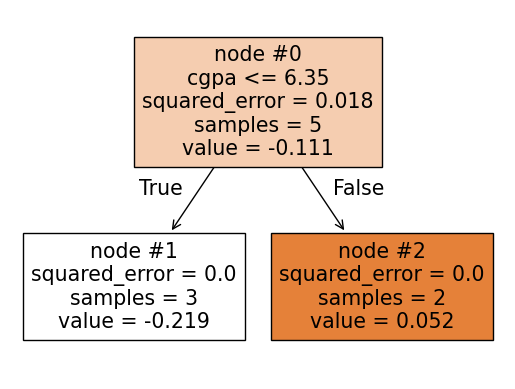

In [131]:
plot_tree(reg2, feature_names=['cgpa','iq'],filled=True, node_ids=True)

In [133]:
placement_df['leaf_entry2'] = reg2.apply(placement_df.iloc[:,0:2])
placement_df

C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes,prob2,prob2(log_loss),residual2,leaf_entry2
0,6.8,123,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2
1,5.9,106,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1
2,5.3,121,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1
3,7.4,132,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2
4,5.8,142,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1


In [134]:
def return_logs(leaf):
  temp_df = placement_df[placement_df['leaf_entry2'] == leaf]
  num = temp_df['residual2'].sum()

  den = sum(temp_df['prob2'] * (1 - temp_df['prob2']))
  return round(num/den,2)

In [135]:
placement_df['prob3(log_loss)'] = placement_df['prob2'] + placement_df['leaf_entry2'].apply(return_logs)

In [136]:
placement_df['prob3'] = 1/(1+np.exp(-placement_df['prob2']))

In [137]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes,prob2,prob2(log_loss),residual2,leaf_entry2,prob3(log_loss),prob3
0,6.8,123,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2,2.007851,0.720683
1,5.9,106,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600
2,5.3,121,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600
3,7.4,132,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2,2.007851,0.720683
4,5.8,142,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600


In [138]:
placement_df['residual3'] = placement_df['placement'] - placement_df['prob3']

In [139]:
placement_df

,cgpa,iq,placement,f0(x),prob1,residual1,leaf_nodes,prob2,prob2(log_loss),residual2,leaf_entry2,prob3(log_loss),prob3,residual3
0,6.8,123,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2,2.007851,0.720683,0.279317
1,5.9,106,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600,-0.554600
2,5.3,121,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600,-0.554600
3,7.4,132,1,-0.405,0.4001,0.5999,2,0.947851,2.9001,0.052149,2,2.007851,0.720683,0.279317
4,5.8,142,0,-0.405,0.4001,-0.4001,1,0.219274,-1.2699,-0.219274,1,-1.060726,0.554600,-0.554600
